scored conditions: ['Baseline', 'H2-only', 'H1-only', 'Full']
policy helpers defined
[saved] 05_contrast1_quantization.csv
[saved] 05_contrast2_model_churn.csv
[saved] 05_contrast3_quality.csv
[saved] 05_approved_default_rate.png  &  05_approved_default_rate.pdf


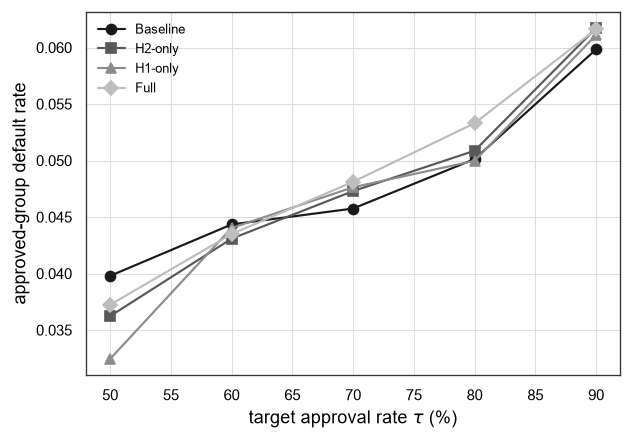

[saved] 05_migration_heatmap.png  &  05_migration_heatmap.pdf


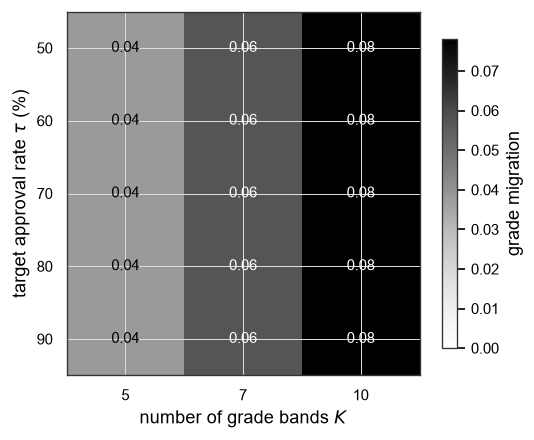

In [1]:
# Notebook 05 — Decision-Impact Simulation (Track C)

import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common as C
C.set_grayscale_style()

X = pd.read_pickle(C.PROC_DIR / "X_all.pkl")
y = np.load(C.PROC_DIR / "y_all.npy")
SP = pickle.load(open(C.PROC_DIR / "splits.pkl", "rb"))
store = pickle.load(open(C.PROC_DIR / "distilled_models.pkl", "rb"))
Xev, yev = X.iloc[SP["eval"]], y[SP["eval"]]

TAUS   = [50, 60, 70, 80, 90]
KS     = [5, 7, 10]
PDO_REP, GRID_REP = 20, 1     # representative deployment quantization

# risk score (higher = riskier) per condition, continuous & integer
def risk_scores(cond):
    obj = store[cond]; sc = obj["scorecard"]; b = obj["binning"]
    Xb = C.apply_binning(Xev, b)
    m_cont = sc.margin(Xb)
    sc.quantize(pdo=PDO_REP, grid=GRID_REP, base_points=600)
    m_int = sc.quantized_margin(Xb)
    return m_cont, m_int

SCORES = {c: risk_scores(c) for c in store}
print("scored conditions:", list(SCORES))


# ----------------------------------------------------------------------------
# approval by target rate tau: approve the (100-tau)%... i.e. approve tau% with
# LOWEST risk. Returns boolean approved mask.
# ----------------------------------------------------------------------------
def approve(risk, tau):
    thr = np.percentile(risk, tau)      # approve the tau% least risky
    return risk <= thr

def banding(risk, k, kind):
    if kind == "equal-frequency":
        return pd.qcut(pd.Series(risk).rank(method="first"), k, labels=False).to_numpy()
    edges = np.linspace(risk.min(), risk.max(), k + 1)
    return np.clip(np.digitize(risk, edges[1:-1]), 0, k - 1)
print("policy helpers defined")


# ----------------------------------------------------------------------------
# Contrast 1: quantized vs continuous grade migration (same model), over tau/K
# ----------------------------------------------------------------------------
rows = []
for cond in SCORES:
    m_cont, m_int = SCORES[cond]
    for tau in TAUS:
        a_cont, a_int = approve(m_cont, tau), approve(m_int, tau)
        flip = float(np.mean(a_cont != a_int))
        for k in KS:
            for kind in ["equal-width", "equal-frequency"]:
                g_cont = banding(m_cont, k, kind)
                g_int = banding(m_int, k, kind)
                rows.append({"condition": cond, "tau": tau, "K": k, "banding": kind,
                             "approval_flip_rate": flip,
                             "grade_migration": float(np.mean(g_cont != g_int))})
c1 = pd.DataFrame(rows)
C.save_table(c1.round(5), "05_contrast1_quantization")
c1[(c1.condition=="Full") & (c1.banding=="equal-frequency")].round(4)


# ----------------------------------------------------------------------------
# Contrast 2: model vs model at same quantization — approved-set churn (Full vs Baseline)
# ----------------------------------------------------------------------------
rows = []
for tau in TAUS:
    a_base = approve(SCORES["Baseline"][1], tau)
    for cond in ["H2-only", "H1-only", "Full"]:
        a_m = approve(SCORES[cond][1], tau)
        inter = np.logical_and(a_base, a_m).sum()
        union = np.logical_or(a_base, a_m).sum()
        rows.append({"tau": tau, "model": f"{cond} vs Baseline",
                     "swap_rate": float(np.mean(a_base != a_m)),
                     "jaccard": float(inter / union) if union else 1.0})
c2 = pd.DataFrame(rows)
C.save_table(c2.round(5), "05_contrast2_model_churn")
c2.round(4)


# ----------------------------------------------------------------------------
# Contrast 3: decision quality — approved-group default rate at same tau (C4
# relative framing). Lower = better selection under a common approval rate.
# ----------------------------------------------------------------------------
rows = []
for tau in TAUS:
    for cond in SCORES:
        a = approve(SCORES[cond][1], tau)
        rows.append({"tau": tau, "condition": cond,
                     "approved_default_rate": float(yev[a].mean()),
                     "approved_n": int(a.sum())})
c3 = pd.DataFrame(rows)
c3_wide = c3.pivot(index="tau", columns="condition",
                   values="approved_default_rate")[list(store)]
C.save_table(c3_wide.round(5).reset_index(), "05_contrast3_quality")
c3_wide.round(4)


# ----------------------------------------------------------------------------
# Figure A: approved-group default rate vs tau, by model (grayscale)
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.4, 3.8))
mk = {"Baseline": ("o", "#1a1a1a"), "H2-only": ("s", "#595959"),
      "H1-only": ("^", "#8c8c8c"), "Full": ("D", "#bdbdbd")}
for cond in store:
    sub = c3[c3.condition == cond].sort_values("tau")
    m, col = mk[cond]
    ax.plot(sub["tau"], sub["approved_default_rate"], marker=m, color=col,
            linewidth=1.3, markersize=6, label=cond)
ax.set_xlabel("target approval rate $\\tau$ (%)")
ax.set_ylabel("approved-group default rate")
ax.legend(fontsize=8)
fig.tight_layout()
C.save_fig(fig, "05_approved_default_rate")
plt.show()


# ----------------------------------------------------------------------------
# Figure B: grade-migration heatmap (quantized vs continuous), Full model,
#   over tau (rows) x K (cols), equal-frequency banding — grayscale
# ----------------------------------------------------------------------------
sub = c1[(c1.condition == "Full") & (c1.banding == "equal-frequency")]
mat = sub.pivot(index="tau", columns="K", values="grade_migration")
fig, ax = plt.subplots(figsize=(4.6, 3.8))
im = ax.imshow(mat.to_numpy(), cmap="Greys", aspect="auto", vmin=0)
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns)
ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
ax.set_xlabel("number of grade bands $K$")
ax.set_ylabel("target approval rate $\\tau$ (%)")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.to_numpy()[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v > mat.to_numpy().max()*0.6 else "black",
                fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.85, label="grade migration")
fig.tight_layout()
C.save_fig(fig, "05_migration_heatmap")
plt.show()
